# Машинное обучение

## Практическое задание №4

Используются данные из Excel-таблицы с информацией об академических работниках.

В ней содержатся следующие переменные:


| Название переменной | Описание переменной 
|:-------------------:|:------------------:|
| burnout | выгорание на работе |
| loc | ощущаемый контроль (чем больше значение, тем меньше ощущение контроля над ситуацией) | 
| cope | способность справляться со сложностями (чем больше значение, тем меньше способность)| 
| teaching | стресс от преподавания (чем выше значение, тем выше уровень стресса)| 
| research | стресс от проведения исследований (чем выше значение, тем выше уровень стресса)| 
| pastoral | стресс от бескорыстной помощи коллегам и студентам (чем выше значение, тем выше уровень стресса)| 
| gender |	пол (мужской, женский)| 
| degree |	наличие ученой степени (phd – кандидат наук, mba - мастер делового администрирования, ms – магистр)| 


Числовые переменные измерены по шкале от 0 до 100.

Ниже перечислены задания, выполненные на основе данных таблицы.

1. Постройте модель бинарной классификации для предсказания переменной burnout, на основе логистической регрессии. Используйте все признаки, предварительно выполнив их предобработку (при необходимости). Разделите данные на обучающую и тестовую выборки, обучите модель и оцените ее качество с помощью метрик классификации (accuracy, precision, recall, F1-score). Постройте ROC-кривую, интерпретируйте её и рассчитайте значение AUC.  На основе полученных метрик сделайте вывод о предсказательной силе модели и её практической применимости.

Сначала добавим нужные библиотеки и исследуем данные

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_curve, roc_auc_score, 
                             classification_report, confusion_matrix)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_excel('burnout.xlsx')
df.head()

,burnout,loc,cope,teaching,research,pastoral,gender,degree
0,Burnt Out,61.764706,81.679389,94.545455,81.250000,96.296296,male,mba
1,Burnt Out,42.941176,39.694656,94.545455,60.416667,87.037037,male,mba
2,Burnt Out,22.352941,17.557252,63.636364,64.583333,68.518519,male,mba
3,Burnt Out,13.529412,25.190840,60.000000,62.500000,66.666667,male,mba
4,Burnt Out,38.235294,34.351145,61.818182,68.750000,61.111111,male,mba


In [79]:
df.describe()

,loc,cope,teaching,research,pastoral
count,467.000000,467.000000,467.000000,467.000000,467.000000
mean,17.900239,23.919120,55.425346,61.906674,55.246253
std,11.928564,15.720822,12.819639,14.738699,13.475945
min,6.470588,3.816794,16.363636,20.833333,18.518519
25%,9.411765,12.213740,47.272727,52.083333,46.296296
50%,14.117647,19.083969,54.545455,62.500000,53.703704
75%,22.352941,31.297710,61.818182,72.916667,62.962963
max,100.000000,100.000000,100.000000,100.000000,100.000000


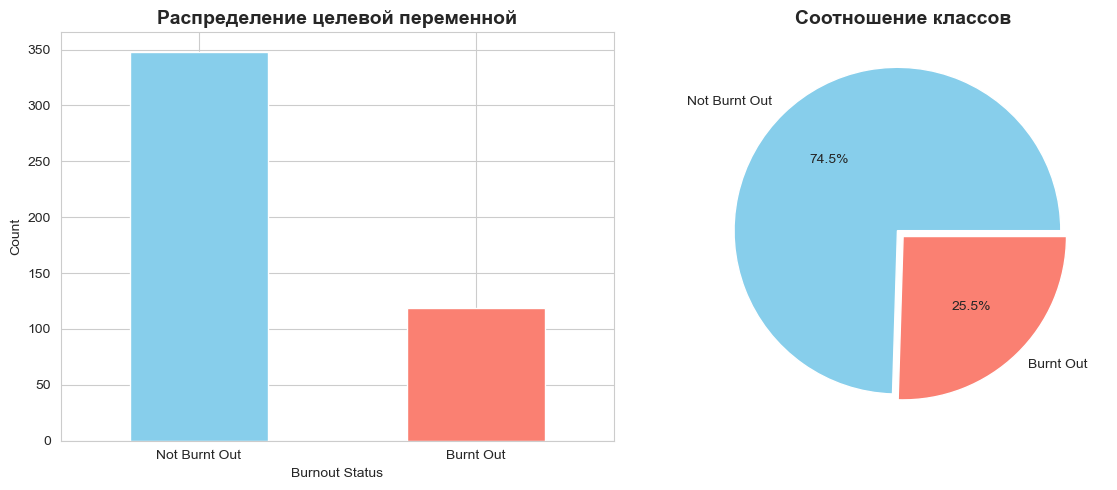

Баланс классов:
Класс 'Burnt Out': 119 наблюдений
Класс 'Not Burnt Out': 348 наблюдений
Соотношение: 2.92:1


In [78]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['burnout'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Распределение целевой переменной', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Burnout Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)


df['burnout'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                   colors=['skyblue', 'salmon'], explode=[0.05, 0])
axes[1].set_title('Соотношение классов', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("Баланс классов:")
print(f"Класс 'Burnt Out': {(df['burnout'] == 'Burnt Out').sum()} наблюдений")
print(f"Класс 'Not Burnt Out': {(df['burnout'] == 'Not Burnt Out').sum()} наблюдений")
print(f"Соотношение: {(df['burnout'] == 'Not Burnt Out').sum() / (df['burnout'] == 'Burnt Out').sum():.2f}:1")

Примерно 1 из 4 человек выгорает по статистике. Лучше сбалансировать далее данные для модели, увеличив вес ошибкам на классе выгоревших.

Для удобства создается копия данных.

Кодируются: 
1. Классы - выгоревшим присваивается 1, не выгоревшим 0.
2. Гендер - женщинам присваивается 0, мужчинам 1.
3. Образование - mba присваивается 0, ms - 1,  phd - 2.

In [65]:
df_processed = df.copy()

le_target = LabelEncoder()
df_processed['burnout_encoded'] = le_target.fit_transform(df_processed['burnout'])

categorical_cols = ['gender', 'degree']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col + '_encoded'] = le.fit_transform(df_processed[col])
    label_encoders[col] = le

Формируем признаки для модели в переменной: ['loc', 'cope', 'teaching', 'research', 'pastoral', 'gender_encoded', 'degree_encoded']


Целевая переменная: burnout_encoded

In [66]:
feature_cols = ['loc', 'cope', 'teaching', 'research', 'pastoral', 
                'gender_encoded', 'degree_encoded']
target_col = 'burnout_encoded'

Исследуем числовые признаки по классам с помощью диаграмм и корреляционной матрицы

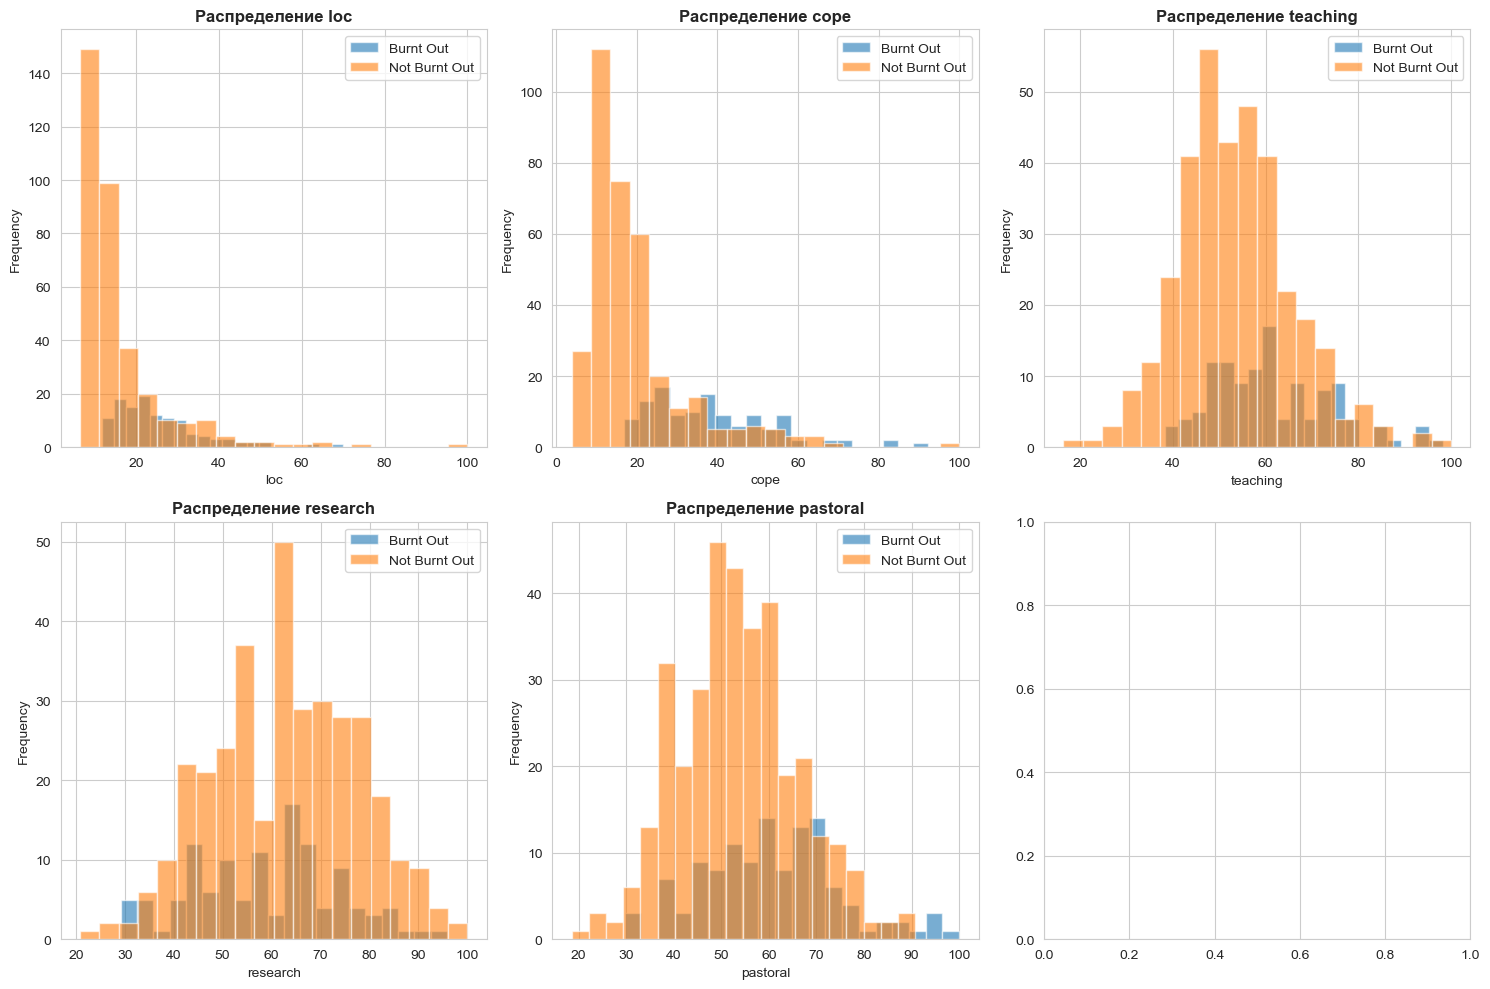

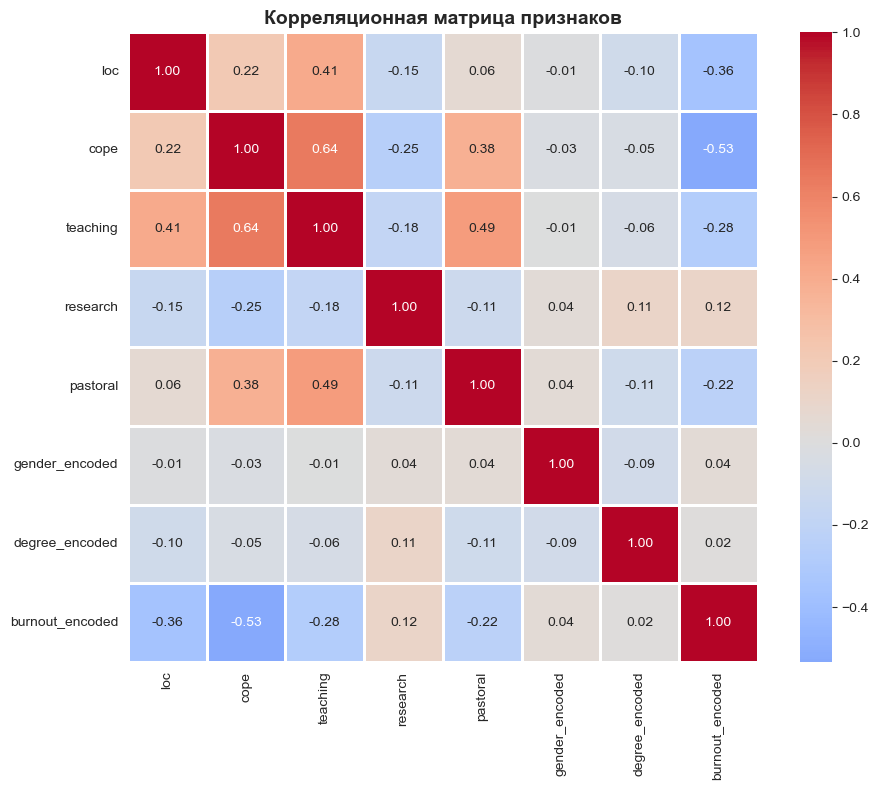

In [67]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
numerical_features = ['loc', 'cope', 'teaching', 'research', 'pastoral']

for idx, feature in enumerate(numerical_features):
    for burnout_class in df['burnout'].unique():
        subset = df[df['burnout'] == burnout_class][feature]
        axes[idx].hist(subset, alpha=0.6, label=burnout_class, bins=20)
    axes[idx].set_title(f'Распределение {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
correlation_matrix = df_processed[feature_cols + [target_col]].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Корреляционная матрица признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Сильная корреляция наблюдается между teaching и  cope, остальные признаки не имеют явно выраженного пересечения и корреляции

Далее готовив выборки для обучения и тестирования модели, стандартизируем признаки

In [69]:
X = df_processed[feature_cols].values
y = df_processed[target_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nРаспределение в train: {np.bincount(y_train)}")
print(f"Распределение в test: {np.bincount(y_test)}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Размер обучающей выборки: (350, 7)
Размер тестовой выборки: (117, 7)

Распределение в train: [ 89 261]
Распределение в test: [30 87]


Создаем и обучаем модель, изучаем результаты и влияние признаков на модель

In [72]:
log_reg = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

y_train_pred = log_reg.predict(X_train_scaled)
y_test_pred = log_reg.predict(X_test_scaled)

y_train_proba = log_reg.predict_proba(X_train_scaled)[:, 1]
y_test_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"Коэффициенты модели: {log_reg.coef_[0].round(4)}")
print(f"Intercept: {log_reg.intercept_[0].round(4)}")

Коэффициенты модели: [-1.2906 -2.1028  1.2351 -0.0023 -0.5579  0.1871  0.0054]
Intercept: 0.4962


Наиболее влияющие на выгорание признаки: 
1. копинг-стратегии - снижает риск выгорания сильнее остальных признаков, шанс выгореть снижается в 8.2 раза
2. ощущаемый контроль - на 2 месте по снижению риска выгорания, шанс выгореть снижается в 3.6 раз
3. преподавание - повышает риск выгорания, шанс выгорания повышается в 3.44 раза

Далее проверим качество модели на обучающих и тест-данных

               precision    recall  f1-score   support

Not Burnt Out       0.58      0.70      0.64        30
    Burnt Out       0.89      0.83      0.86        87

     accuracy                           0.79       117
    macro avg       0.74      0.76      0.75       117
 weighted avg       0.81      0.79      0.80       117



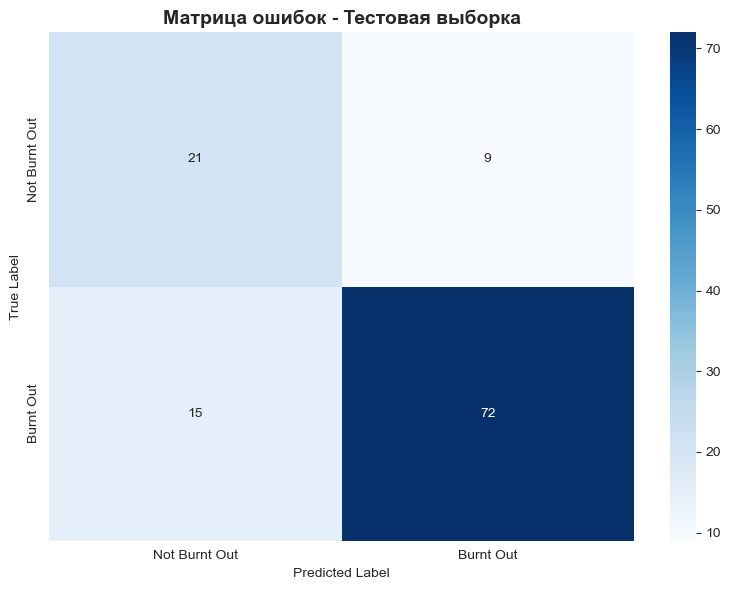

In [76]:
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Train': [train_accuracy, train_precision, train_recall, train_f1],
    'Test': [test_accuracy, test_precision, test_recall, test_f1]
})

metrics_df.to_string(index=False)
print(classification_report(y_test, y_test_pred, 
                           target_names=['Not Burnt Out', 'Burnt Out']))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Burnt Out', 'Burnt Out'],
            yticklabels=['Not Burnt Out', 'Burnt Out'])
plt.title('Матрица ошибок - Тестовая выборка', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

Модель отлично определяет выгоревших сотрудников - показатель правильно найденного выгорания (ТР) 72.

Если модель прогнозирует выгорание - то это достаточно надежное предсказание (89% надежности), но если говорит, что нет выгорания, то нужно верить осторожно (42% здоровых могут получить ложный диагноз выгорания).

Риск пропуска случая выгорания - 17%.


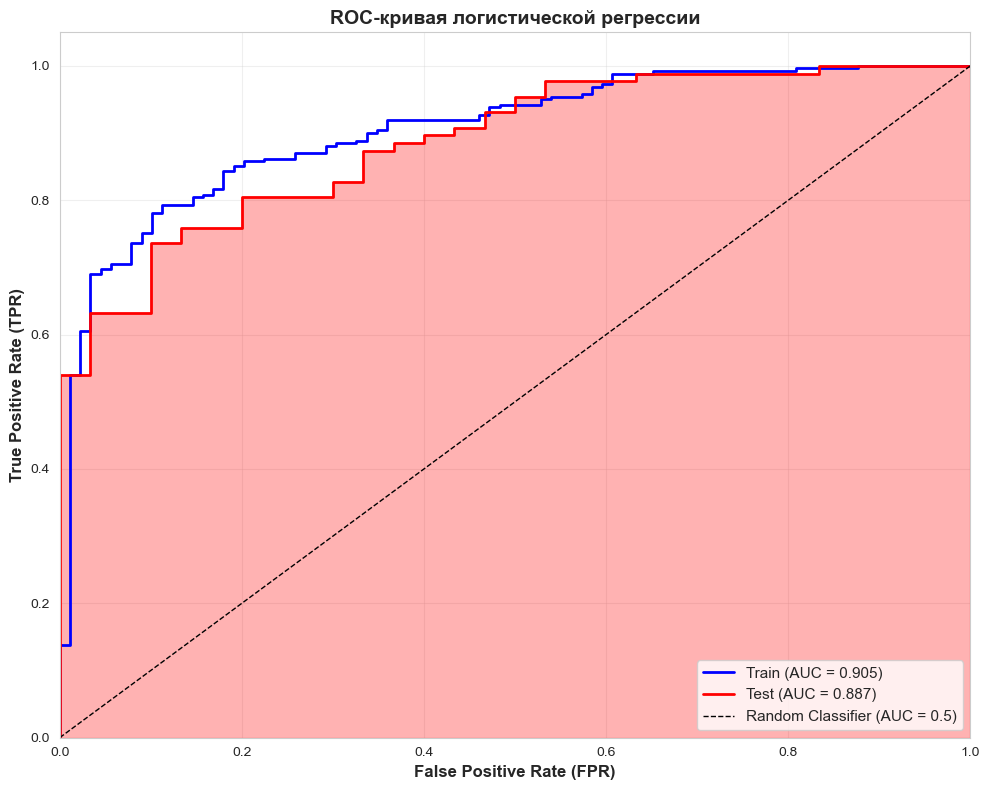

AUC на обучающей выборке: 0.9051
AUC на тестовой выборке: 0.8870
Разница между train и test: 0.0181


In [27]:
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
auc_train = roc_auc_score(y_train, y_train_proba)

fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, label=f'Train (AUC = {auc_train:.3f})', 
         linewidth=2, color='blue')
plt.plot(fpr_test, tpr_test, label=f'Test (AUC = {auc_test:.3f})', 
         linewidth=2, color='red')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)', linewidth=1)
plt.fill_between(fpr_test, tpr_test, alpha=0.3, color='red')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold')
plt.title('ROC-кривая логистической регрессии', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC на обучающей выборке: {auc_train:.4f}")
print(f"AUC на тестовой выборке: {auc_test:.4f}")
print(f"Разница между train и test: {abs(auc_train - auc_test):.4f}")

На основе AUC анализа примерно в 89% случаев модель правильно определит, у кого выше риск выгорания. Разница между результатами train и test 0.0181 говорит о стабильности модели и отсутствии переобучения

2. Интерпретируйте коэффициенты обученной модели логистической регрессии через отношения шансов (odds ratios) и предельные эффекты (marginal effects). Графически сравните важность признаков. На основе полученных результатов сделайте выводы о том, какие факторы в наибольшей степени связаны с вероятностью выгорания и как именно они на неё влияют.

Посмотрим коэффициенты и их стандартные ошибки с помощью ковариационной матрицы и бутстрапа.

In [86]:
import scipy.stats as stats

coefficients = log_reg.coef_[0]
intercept = log_reg.intercept_[0]

try:
    log_reg_coef_se = np.sqrt(np.diag(log_reg._get_param_names()))
except:

    from sklearn.utils import resample
    n_bootstrap = 100
    bootstrap_coefs = []
    for _ in range(n_bootstrap):
        X_boot, y_boot = resample(X_train_scaled, y_train, random_state=_)
        boot_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
        boot_model.fit(X_boot, y_boot)
        bootstrap_coefs.append(boot_model.coef_[0])
    bootstrap_coefs = np.array(bootstrap_coefs)
    coef_se = bootstrap_coefs.std(axis=0)
    coef_means = bootstrap_coefs.mean(axis=0)
else:
    coef_means = coefficients
    coef_se = log_reg_coef_se

Рассчитаем odds ratio

In [85]:
odds_ratios = np.exp(coefficients)
odds_ratios_ci_lower = np.exp(coefficients - 1.96 * coef_se)
odds_ratios_ci_upper = np.exp(coefficients + 1.96 * coef_se)

Далее посмотрим ключевые признаки

In [93]:
interpretation_df = pd.DataFrame({
    'Признак': feature_cols,
    'Коэффициент': coefficients.round(4),
    'Odds Ratio': odds_ratios.round(4),
    '95% CI Lower': odds_ratios_ci_lower.round(4),
    '95% CI Upper': odds_ratios_ci_upper.round(4),
    'Влияние': ['Увеличивает' if or_ > 1 else 'Уменьшает' for or_ in odds_ratios]
})

print(interpretation_df.to_string(index=False))

       Признак  Коэффициент  Odds Ratio  95% CI Lower  95% CI Upper     Влияние
           loc      -1.2906      0.2751        0.1644        0.4603   Уменьшает
          cope      -2.1028      0.1221        0.0695        0.2146   Уменьшает
      teaching       1.2351      3.4388        2.0028        5.9045 Увеличивает
      research      -0.0023      0.9977        0.6563        1.5168   Уменьшает
      pastoral      -0.5579      0.5724        0.3637        0.9011   Уменьшает
gender_encoded       0.1871      1.2058        0.8933        1.6275 Увеличивает
degree_encoded       0.0054      1.0054        0.7187        1.4064 Увеличивает


• loc: Odds Ratio = 0.275
  → При увеличении ощущения контроля на 1 стандартное отклонение,
    шансы выгорания уменьшаются на 72.5%
    (доверительный интервал: [0.164; 0.460])

• cope: Odds Ratio = 0.122
  → При увеличении показателя копинг-стратегий на 1 стандартное отклонение,
    шансы выгорания уменьшаются на 87.8%
    (доверительный интервал: [0.070; 0.215])

• teaching: Odds Ratio = 3.439
  → При увеличении стресса от преподавания на 1 стандартное отклонение,
    шансы выгорания увеличиваются в 3.44 раза
    (доверительный интервал: [2.003; 5.904])

• pastoral: Odds Ratio = 0.572
  → При увеличении стресса от бескорыстной помощи на 1 стандартное отклонение,
    шансы выгорания уменьшаются на 42.8%
    (доверительный интервал: [0.364; 0.901])

Визуализируем Odds Ratios с доверительными интервалами

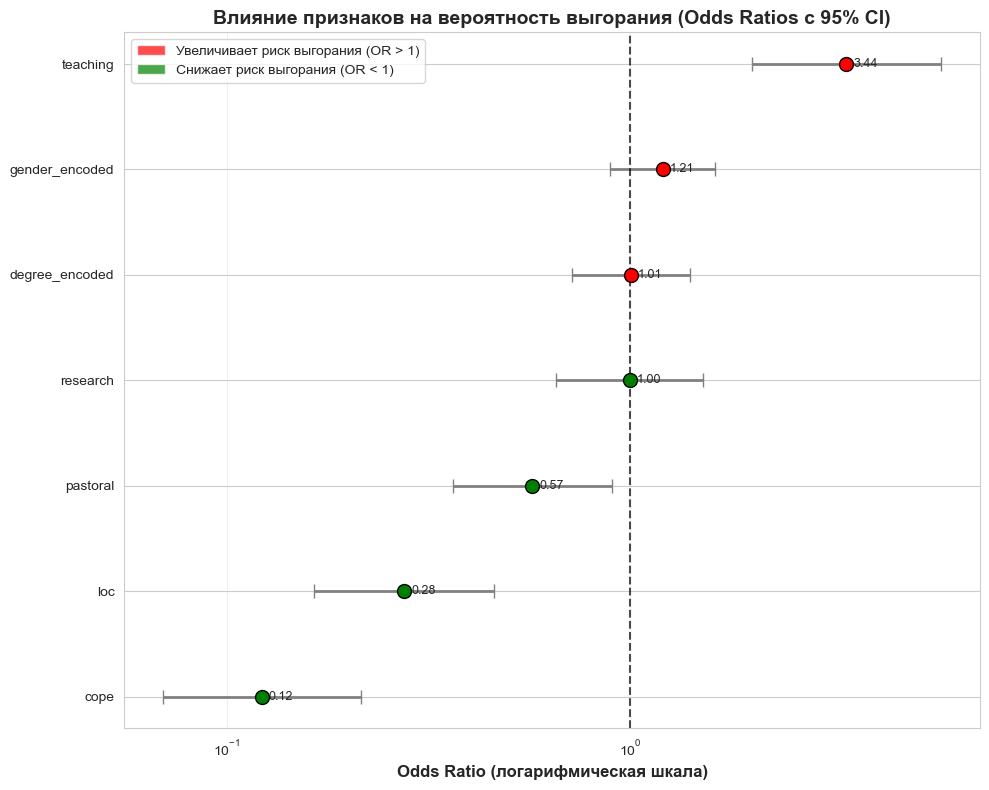

In [96]:
fig, ax = plt.subplots(figsize=(10, 8))

interpretation_df_sorted = interpretation_df.sort_values('Odds Ratio', ascending=True)

y_pos = np.arange(len(interpretation_df_sorted))
odds_ratios_sorted = interpretation_df_sorted['Odds Ratio'].values
ci_lower_sorted = interpretation_df_sorted['95% CI Lower'].values
ci_upper_sorted = interpretation_df_sorted['95% CI Upper'].values
features_sorted = interpretation_df_sorted['Признак'].values

for i, (or_val, feature, color_idx) in enumerate(zip(odds_ratios_sorted, features_sorted, range(len(odds_ratios_sorted)))):
    if or_val > 1:
        point_color = 'red'
    else:
        point_color = 'green'
    
    ax.errorbar(or_val, i, 
                xerr=[[or_val - ci_lower_sorted[i]], [ci_upper_sorted[i] - or_val]],
                fmt='o', capsize=5, capthick=2, elinewidth=2,
                markersize=10, color=point_color, ecolor='gray', markeredgecolor='black',
                markeredgewidth=1)

ax.axvline(x=1, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='Нулевой эффект (OR=1)')

ax.set_yticks(y_pos)
ax.set_yticklabels(features_sorted)
ax.set_xlabel('Odds Ratio (логарифмическая шкала)', fontsize=12, fontweight='bold')
ax.set_title('Влияние признаков на вероятность выгорания (Odds Ratios с 95% CI)', 
             fontsize=14, fontweight='bold')
ax.set_xscale('log') 
ax.grid(True, alpha=0.3, axis='x')

for i, (or_val, feature) in enumerate(zip(odds_ratios_sorted, features_sorted)):
    ax.annotate(f'{or_val:.2f}', 
                xy=(or_val, i),
                xytext=(5, 0), textcoords='offset points',
                fontsize=9, ha='left', va='center')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', alpha=0.7, label='Увеличивает риск выгорания (OR > 1)'),
                   Patch(facecolor='green', alpha=0.7, label='Снижает риск выгорания (OR < 1)')]
ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()

Защитные факторы против выгорания: копинг-стратегии, ощущение контроля и бескорыстная помощь окружающим.

Факторы риска: стресс от преподавания.

Незначимые факторы: гендер, наличие ученой степени и стресс от проведения исследований.

Посмотрим силу влияния признаков на графиках.

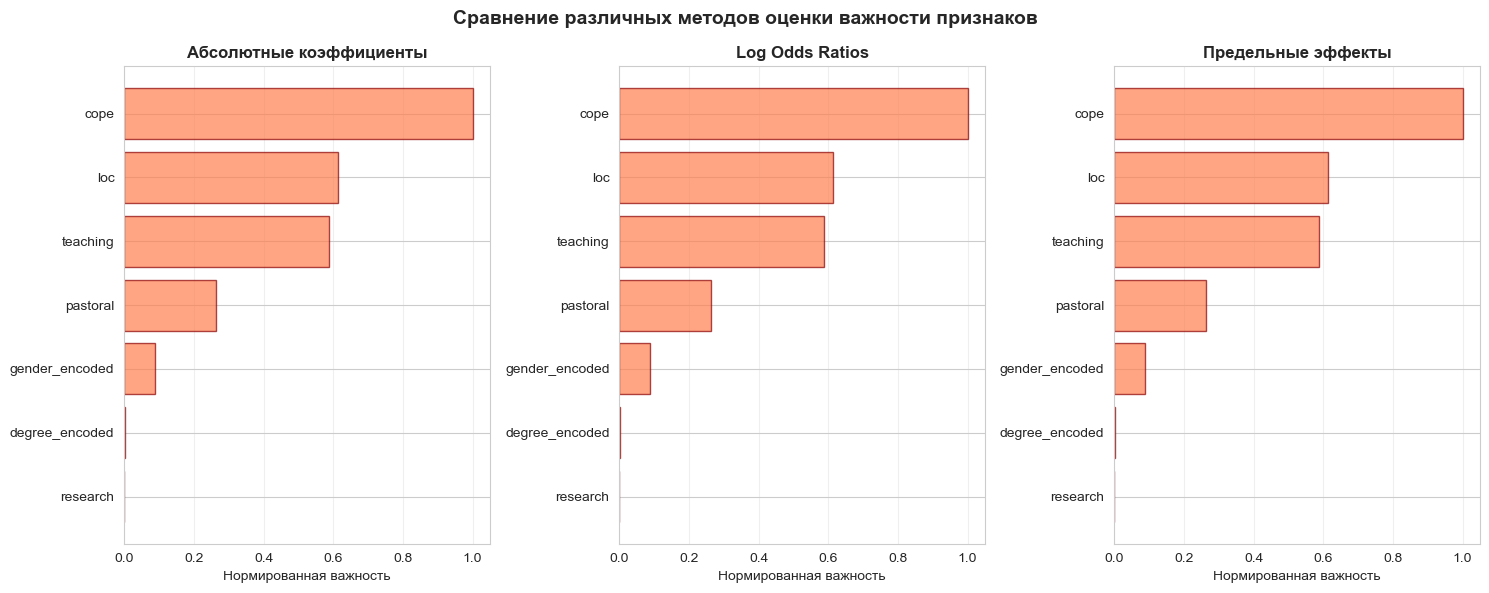

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

metrics = ['Коэффициент (абс.) (норм.)', 'Odds Ratio (лог) (норм.)', 'Предельный эффект (абс.) (норм.)']
titles = ['Абсолютные коэффициенты', 'Log Odds Ratios', 'Предельные эффекты']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    importance_sorted = importance_comparison.sort_values(metric, ascending=True)
    axes[idx].barh(importance_sorted['Признак'], importance_sorted[metric], 
                   color='coral', alpha=0.7, edgecolor='darkred')
    axes[idx].set_xlabel('Нормированная важность', fontsize=10)
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='x')

plt.suptitle('Сравнение различных методов оценки важности признаков', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Итоговые выводы

1. Факторы, увеличивающие риск выгорания

   • teaching:
     - Odds Ratio = 3.439
     - Предельный эффект = 0.2919
     - Увеличение признака на 1 стандартное отклонение повышает шансы выгорания в 3.44 раза

   • gender_encoded:
     - Odds Ratio = 1.206
     - Предельный эффект = 0.0442
     - Увеличение признака на 1 стандартное отклонение повышает шансы выгорания в 1.21 раза

   • degree_encoded:
     - Odds Ratio = 1.005
     - Предельный эффект = 0.0013
     - Увеличение признака на 1 стандартное отклонение повышает шансы выгорания в 1.01 раза

2. Факторы, снижающие риск выгорания

   • cope:
     - Odds Ratio = 0.122
     - Предельный эффект = -0.4970
     - Увеличение признака на 1 стандартное отклонение снижает шансы выгорания на 87.8%

   • loc:
     - Odds Ratio = 0.275
     - Предельный эффект = -0.3050
     - Увеличение признака на 1 стандартное отклонение снижает шансы выгорания на 72.5%

   • pastoral:
     - Odds Ratio = 0.572
     - Предельный эффект = -0.1318
     - Увеличение признака на 1 стандартное отклонение снижает шансы выгорания на 42.8%

3. Закономерности
   • loc (локация):
     - OR = 0.275, ME = -0.3050
     - Чем выше показатель, тем ниже риск выгорания

   • cope (копинг-стратегии):
     - OR = 0.122, ME = -0.4970
     - Чем выше показатель, тем ниже риск выгорания

   • teaching (обучение):
     - OR = 3.439, ME = 0.2919
     - Высокая нагрузка в этой сфере увеличивает риск выгорания

   • research (научные работы):
     - OR = 0.998, ME = -0.0005
     - Высокая нагрузка в этой сфере снижает риск выгорания

   • pastoral (эмоциональная поддержка):
     - OR = 0.572, ME = -0.1318
     - Высокая нагрузка в этой сфере снижает риск выгорания

Наиболее сильное влияние на вероятность выгорания оказывают:
  • Положительное: teaching (OR=3.439)
  • Отрицательное: cope (OR=0.122)

3. Оцените влияние регуляризации на результаты модели логистической регрессии. Обучите модели с различными типами регуляризации. Сравните полученные коэффициенты. Проанализируйте изменения в качестве модели. Сделайте вывод о том, как регуляризация влияет на переобучение, интерпретируемость модели и вклад признаков, и какая конфигурация оказалась наиболее эффективной.

Добавляем библиотеки и переменные для хранения данных

In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

models_results = {}
coefs_dict = {}

Создаем разные типы регуляризации и обучаем модели с разными типами регуляризации. Выведем результаты с проверкой точности работы

In [106]:
regularization_types = {
    'No Regularization': {'penalty': None, 'solver': 'lbfgs', 'C': 1.0},
    'L1 (Lasso)': {'penalty': 'l1', 'solver': 'saga', 'C': 1.0},
    'L2 (Ridge)': {'penalty': 'l2', 'solver': 'lbfgs', 'C': 1.0},
    'ElasticNet': {'penalty': 'elasticnet', 'solver': 'saga', 'C': 1.0, 'l1_ratio': 0.5}
}

for name, params in regularization_types.items():
    print(f"\nОбучение модели: {name}")
    try:
        if name == 'ElasticNet':
            model = LogisticRegression(
                penalty=params['penalty'],
                solver=params['solver'],
                C=params['C'],
                l1_ratio=params['l1_ratio'],
                random_state=42,
                max_iter=2000,
                class_weight='balanced'
            )
        elif name == 'No Regularization':
            model = LogisticRegression(
                penalty=params['penalty'],
                solver=params['solver'],
                random_state=42,
                max_iter=2000,
                class_weight='balanced'
            )
        else:
            model = LogisticRegression(
                penalty=params['penalty'],
                solver=params['solver'],
                C=params['C'],
                random_state=42,
                max_iter=2000,
                class_weight='balanced'
            )
        
        model.fit(X_train_scaled, y_train)
        
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)
        y_train_proba = model.predict_proba(X_train_scaled)[:, 1]
        y_test_proba = model.predict_proba(X_test_scaled)[:, 1]
        
        models_results[name] = {
            'model': model,
            'train_accuracy': accuracy_score(y_train, y_train_pred),
            'test_accuracy': accuracy_score(y_test, y_test_pred),
            'train_precision': precision_score(y_train, y_train_pred),
            'test_precision': precision_score(y_test, y_test_pred),
            'train_recall': recall_score(y_train, y_train_pred),
            'test_recall': recall_score(y_test, y_test_pred),
            'train_f1': f1_score(y_train, y_train_pred),
            'test_f1': f1_score(y_test, y_test_pred),
            'train_auc': roc_auc_score(y_train, y_train_proba),
            'test_auc': roc_auc_score(y_test, y_test_proba),
            'coefs': model.coef_[0],
            'n_features_nonzero': np.sum(np.abs(model.coef_[0]) > 1e-6)
        }
        
        coefs_dict[name] = model.coef_[0]
        
        print(f"    Test Accuracy: {models_results[name]['test_accuracy']:.4f}")
        print(f"    Test F1: {models_results[name]['test_f1']:.4f}")
        print(f"    Ненулевых коэффициентов: {models_results[name]['n_features_nonzero']}")
        
    except Exception as e:
        print(f"  Ошибка при обучении {name}: {str(e)}")
        models_results[name] = None


Обучение модели: No Regularization
    Test Accuracy: 0.7863
    Test F1: 0.8503
    Ненулевых коэффициентов: 7

Обучение модели: L1 (Lasso)
    Test Accuracy: 0.7949
    Test F1: 0.8571
    Ненулевых коэффициентов: 5

Обучение модели: L2 (Ridge)
    Test Accuracy: 0.7949
    Test F1: 0.8571
    Ненулевых коэффициентов: 7

Обучение модели: ElasticNet
    Test Accuracy: 0.7949
    Test F1: 0.8571
    Ненулевых коэффициентов: 5


Создадим визуализацию со сравнением работы разных типов регуляризации

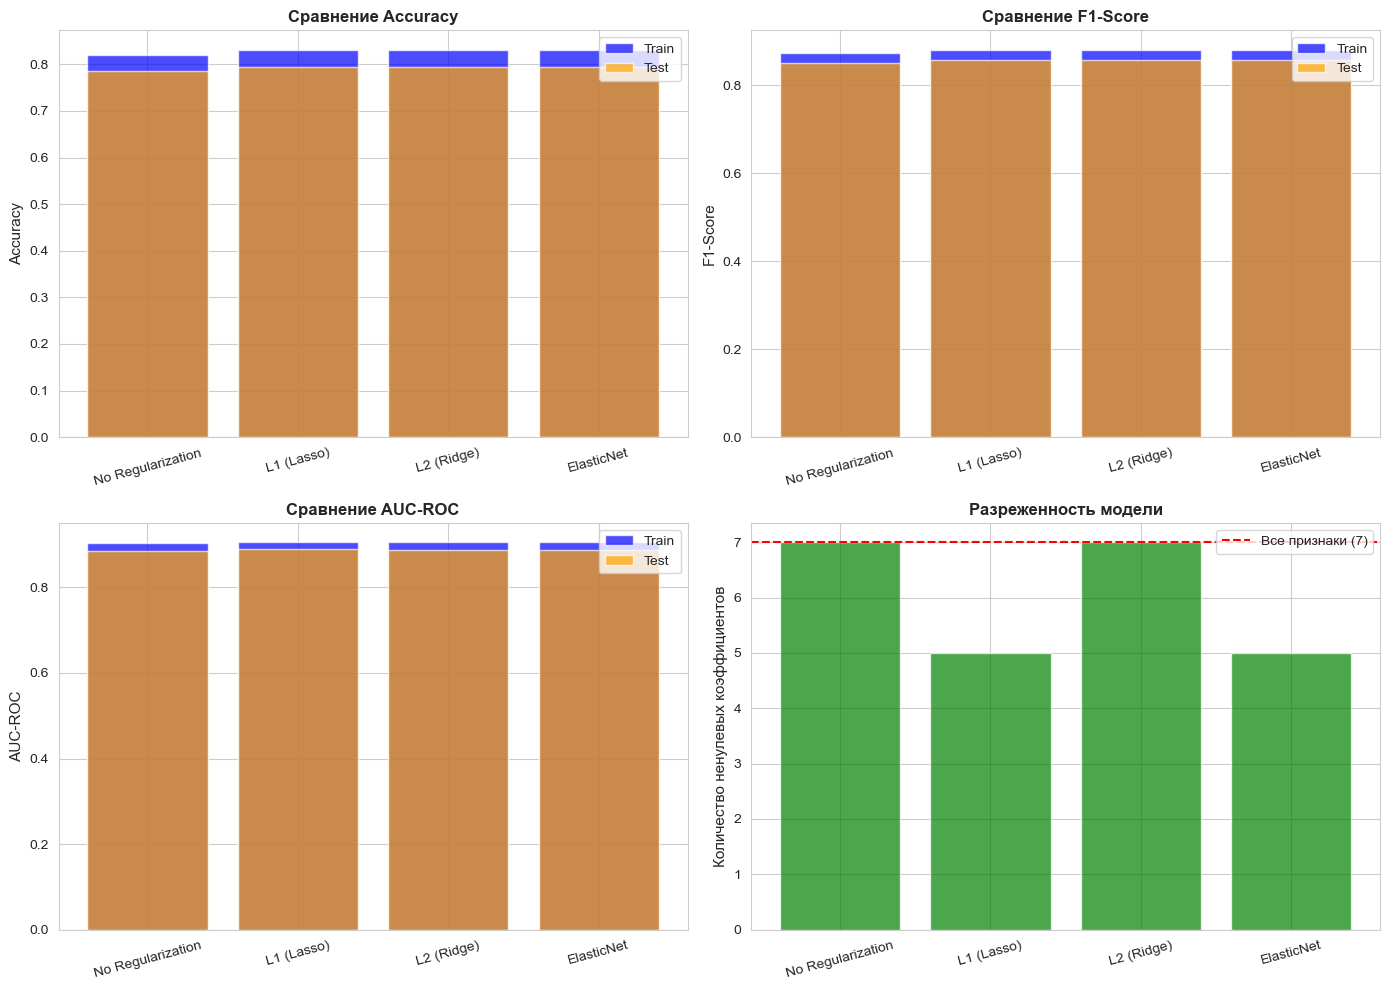

In [110]:
comparison_data = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(comparison_df['Тип регуляризации'], comparison_df['Train Acc'], 
               alpha=0.7, label='Train', color='blue')
axes[0, 0].bar(comparison_df['Тип регуляризации'], comparison_df['Test Acc'], 
               alpha=0.7, label='Test', color='orange')
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].set_title('Сравнение Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=15)

axes[0, 1].bar(comparison_df['Тип регуляризации'], comparison_df['Train F1'], 
               alpha=0.7, label='Train', color='blue')
axes[0, 1].bar(comparison_df['Тип регуляризации'], comparison_df['Test F1'], 
               alpha=0.7, label='Test', color='orange')
axes[0, 1].set_ylabel('F1-Score', fontsize=11)
axes[0, 1].set_title('Сравнение F1-Score', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=15)

axes[1, 0].bar(comparison_df['Тип регуляризации'], comparison_df['Train AUC'], 
               alpha=0.7, label='Train', color='blue')
axes[1, 0].bar(comparison_df['Тип регуляризации'], comparison_df['Test AUC'], 
               alpha=0.7, label='Test', color='orange')
axes[1, 0].set_ylabel('AUC-ROC', fontsize=11)
axes[1, 0].set_title('Сравнение AUC-ROC', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].tick_params(axis='x', rotation=15)

axes[1, 1].bar(comparison_df['Тип регуляризации'], comparison_df['Non-zero Coefs'], 
               color='green', alpha=0.7)
axes[1, 1].set_ylabel('Количество ненулевых коэффициентов', fontsize=11)
axes[1, 1].set_title('Разреженность модели', fontsize=12, fontweight='bold')
axes[1, 1].axhline(y=7, color='red', linestyle='--', label='Все признаки (7)')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

Тип регуляризации радикально не влияет на качество предсказаний в этой модели.
Методы L1 и ElasticNet обнуляют 2 признака и учитывают в расчете предсказания только 3 параметра.

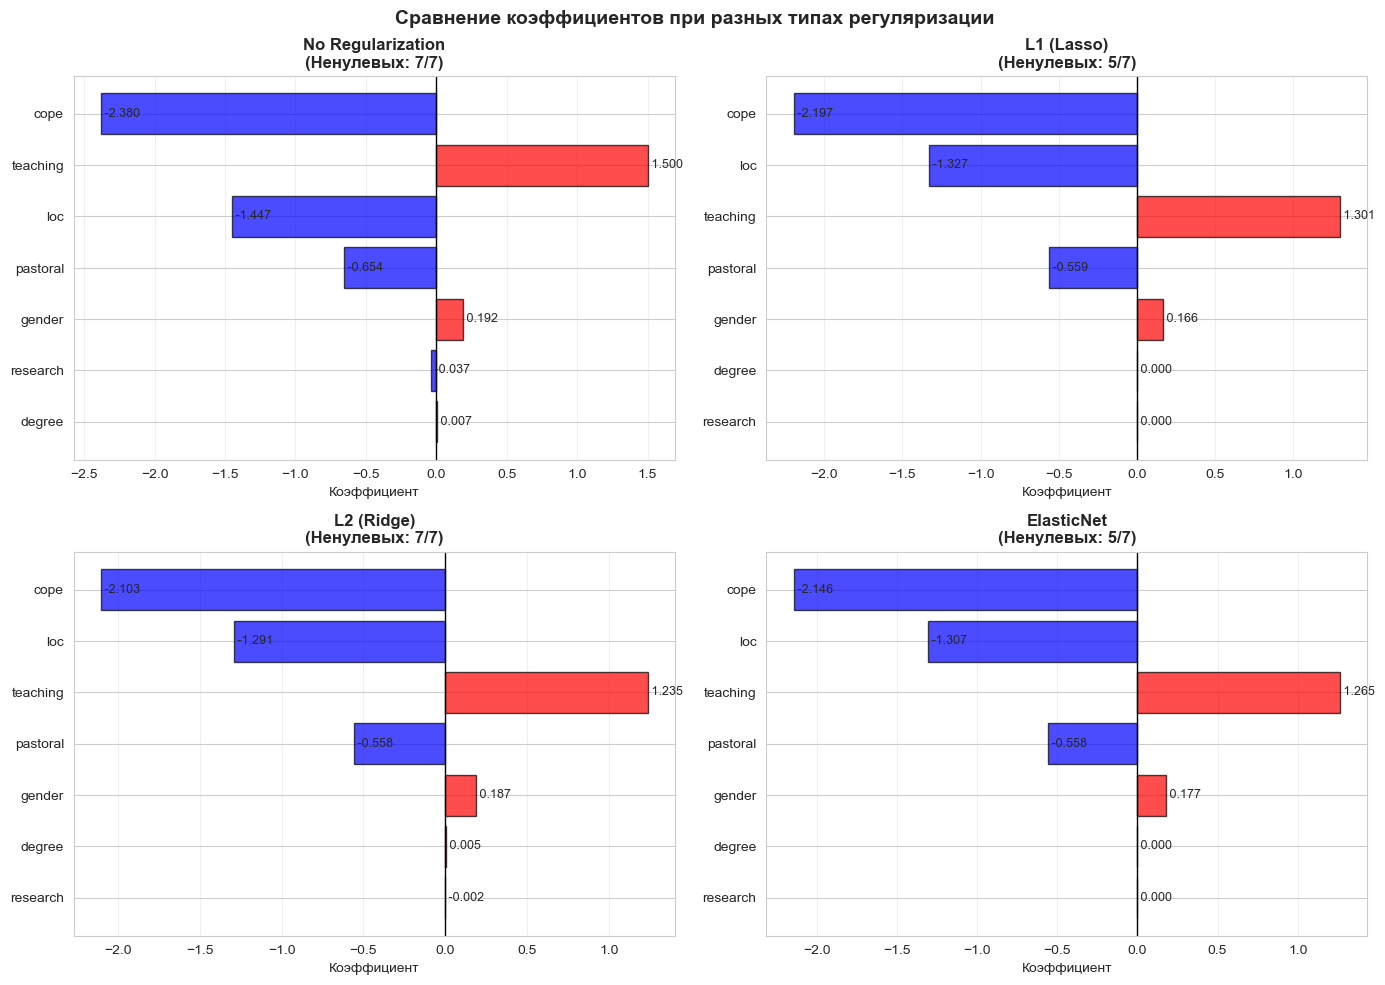


No Regularization:
  Среднее |коэф|: 0.8881
  Макс |коэф|: 2.3801
  Стандартное отклонение: 1.1551

L1 (Lasso):
  Среднее |коэф|: 0.7929
  Макс |коэф|: 2.1967
  Стандартное отклонение: 1.0448

L2 (Ridge):
  Среднее |коэф|: 0.7687
  Макс |коэф|: 2.1028
  Стандартное отклонение: 1.0034

ElasticNet:
  Среднее |коэф|: 0.7788
  Макс |коэф|: 2.1458
  Стандартное отклонение: 1.0219


In [112]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

feature_names = ['loc', 'cope', 'teaching', 'research', 'pastoral', 'gender', 'degree']

for idx, (name, results) in enumerate(models_results.items()):
    if results is not None and idx < 4:
        coefs = results['coefs']
        
        sorted_idx = np.argsort(np.abs(coefs))
        coefs_sorted = coefs[sorted_idx]
        features_sorted = [feature_names[i] for i in sorted_idx]
        
        colors = ['red' if c > 0 else 'blue' for c in coefs_sorted]
        
        axes[idx].barh(features_sorted, coefs_sorted, color=colors, alpha=0.7, edgecolor='black')
        axes[idx].axvline(x=0, color='black', linestyle='-', linewidth=1)
        axes[idx].set_xlabel('Коэффициент', fontsize=10)
        axes[idx].set_title(f'{name}\n(Ненулевых: {results["n_features_nonzero"]}/7)', 
                           fontsize=12, fontweight='bold')
        axes[idx].grid(True, alpha=0.3, axis='x')

        for i, (coef, feature) in enumerate(zip(coefs_sorted, features_sorted)):
            axes[idx].text(coef, i, f' {coef:.3f}', va='center', fontsize=9)

plt.suptitle('Сравнение коэффициентов при разных типах регуляризации', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

for name in models_results.keys():
    if models_results[name] is not None:
        coefs = models_results[name]['coefs']
        print(f"\n{name}:")
        print(f"  Среднее |коэф|: {np.mean(np.abs(coefs)):.4f}")
        print(f"  Макс |коэф|: {np.max(np.abs(coefs)):.4f}")
        print(f"  Стандартное отклонение: {np.std(coefs):.4f}")

Основные выводы:
1. Регуляризация уменьшает величину коэффициентов, L2 делает это наиболее сильно.
2. L2 сильнее ограничивает самые большие коэффициенты.
3. Регуляризация выравнивает коэффициенты, L2 создает наиболее "сглаженную" модель.

Лучше использовать в данной модели L2, так как она дает лучшее сжатие, сохраняет все признаки и стабильнее на новых данных.

In [ ]:
Проведем анализ Grid Search для разных типов регуляризации

In [117]:
C_values = [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 50, 100]

l2_model = LogisticRegression(
    penalty='l2', 
    solver='lbfgs', 
    random_state=42, 
    max_iter=2000,
    class_weight='balanced'
)

param_grid = {'C': C_values}
grid_l2 = GridSearchCV(
    l2_model, 
    param_grid, 
    cv=5, 
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
grid_l2.fit(X_train_scaled, y_train)

l1_model = LogisticRegression(
    penalty='l1', 
    solver='saga', 
    random_state=42, 
    max_iter=2000,
    class_weight='balanced'
)

grid_l1 = GridSearchCV(
    l1_model, 
    param_grid, 
    cv=5, 
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
grid_l1.fit(X_train_scaled, y_train)

en_model = LogisticRegression(
    penalty='elasticnet', 
    solver='saga', 
    l1_ratio=0.5,
    random_state=42, 
    max_iter=2000,
    class_weight='balanced'
)

grid_en = GridSearchCV(
    en_model, 
    param_grid, 
    cv=5, 
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
grid_en.fit(X_train_scaled, y_train)

print("Результаты grid search")
print("\n")
print(f"Лучший C для L2: {grid_l2.best_params_['C']} (AUC: {grid_l2.best_score_:.4f})")
print(f"Лучший C для L1: {grid_l1.best_params_['C']} (AUC: {grid_l1.best_score_:.4f})")
print(f"Лучший C для ElasticNet: {grid_en.best_params_['C']} (AUC: {grid_en.best_score_:.4f})")

Результаты grid search


Лучший C для L2: 0.1 (AUC: 0.8918)
Лучший C для L1: 0.1 (AUC: 0.8948)
Лучший C для ElasticNet: 0.1 (AUC: 0.8918)


Разница в результатах минимальныя, наиболее оптимальным оказался L1 - у нее выше интерпретируемость и лучше AUC.

Далее протестируем лучшие модели на тестовой выборке. 

In [118]:

best_models = {
    'L2 (C={})'.format(grid_l2.best_params_['C']): grid_l2.best_estimator_,
    'L1 (C={})'.format(grid_l1.best_params_['C']): grid_l1.best_estimator_,
    'ElasticNet (C={})'.format(grid_en.best_params_['C']): grid_en.best_estimator_
}

best_results = {}

for name, model in best_models.items():
    y_test_pred = model.predict(X_test_scaled)
    y_test_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_proba)
    n_nonzero = np.sum(np.abs(model.coef_[0]) > 1e-6)
    
    best_results[name] = {
        'Test Accuracy': test_acc,
        'Test F1': test_f1,
        'Test AUC': test_auc,
        'Non-zero Coefs': n_nonzero,
        'Sparsity %': (n_nonzero / 7) * 100
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy: {test_acc:.4f}")
    print(f"  F1-Score: {test_f1:.4f}")
    print(f"  AUC: {test_auc:.4f}")
    print(f"  Использовано признаков: {n_nonzero}/7 ({100*n_nonzero/7:.0f}%)")


L2 (C=0.1):
  Accuracy: 0.7863
  F1-Score: 0.8521
  AUC: 0.8793
  Использовано признаков: 7/7 (100%)

L1 (C=0.1):
  Accuracy: 0.7949
  F1-Score: 0.8571
  AUC: 0.8962
  Использовано признаков: 4/7 (57%)

ElasticNet (C=0.1):
  Accuracy: 0.7949
  F1-Score: 0.8571
  AUC: 0.8939
  Использовано признаков: 6/7 (86%)


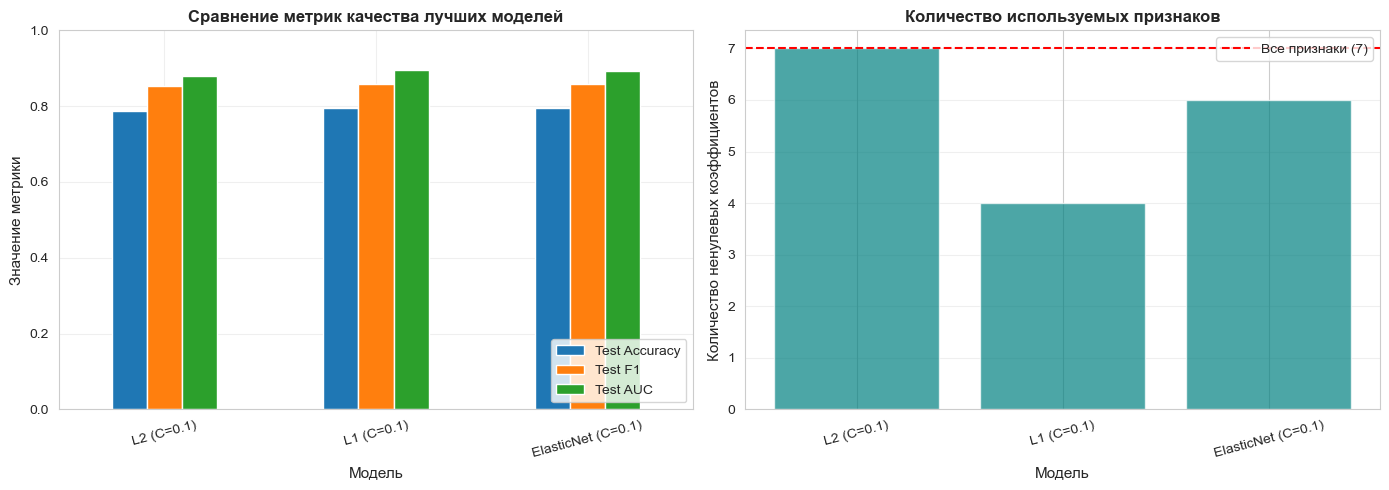

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_df = pd.DataFrame(best_results).T
metrics_df[['Test Accuracy', 'Test F1', 'Test AUC']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Сравнение метрик качества лучших моделей', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Значение метрики', fontsize=11)
axes[0].set_xlabel('Модель', fontsize=11)
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, alpha=0.3)

axes[1].bar(metrics_df.index, metrics_df['Non-zero Coefs'], color='teal', alpha=0.7)
axes[1].set_title('Количество используемых признаков', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Количество ненулевых коэффициентов', fontsize=11)
axes[1].set_xlabel('Модель', fontsize=11)
axes[1].axhline(y=7, color='red', linestyle='--', label='Все признаки (7)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Лучше всего в модели применить тип регуляризации L1.
1. Он использует 4 признака, упростил формулу выгорания
2. Правильно классифицирует около 80% выгоревших
3. На 85,7% соблюдает баланс между точностью и полнотой
4. Достаточно хорошо разделяет результаты - AUC 89,6%

4. Постройте аналогичную модель классификации на основе метода k ближайших соседей. Проведите подбор оптимального значения параметра k с использованием кросс-валидации. Обучите финальную модель с выбранным значением k и оцените качество модели на тестовой выборке. Проанализируйте ошибки классификации. Оцените важность признаков. Сделайте вывод о влиянии параметра k на переобучение и недообучение модели.

Импортируем дополнительные библиотеки

In [120]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

Исследуем влияение k на качество модели

k=5: Train Acc=0.8943, Test Acc=0.8291, CV=0.8514 (+/-0.0357)
k=10: Train Acc=0.8914, Test Acc=0.7949, CV=0.8543 (+/-0.0455)
k=15: Train Acc=0.8743, Test Acc=0.8120, CV=0.8486 (+/-0.0308)
k=20: Train Acc=0.8657, Test Acc=0.8034, CV=0.8429 (+/-0.0394)
k=25: Train Acc=0.8486, Test Acc=0.8291, CV=0.8429 (+/-0.0326)
k=30: Train Acc=0.8429, Test Acc=0.8205, CV=0.8229 (+/-0.0475)
k=35: Train Acc=0.8371, Test Acc=0.8205, CV=0.8171 (+/-0.0331)
k=40: Train Acc=0.8286, Test Acc=0.8205, CV=0.8114 (+/-0.0455)
k=45: Train Acc=0.8257, Test Acc=0.8034, CV=0.8114 (+/-0.0331)
k=50: Train Acc=0.8200, Test Acc=0.7949, CV=0.8114 (+/-0.0398)


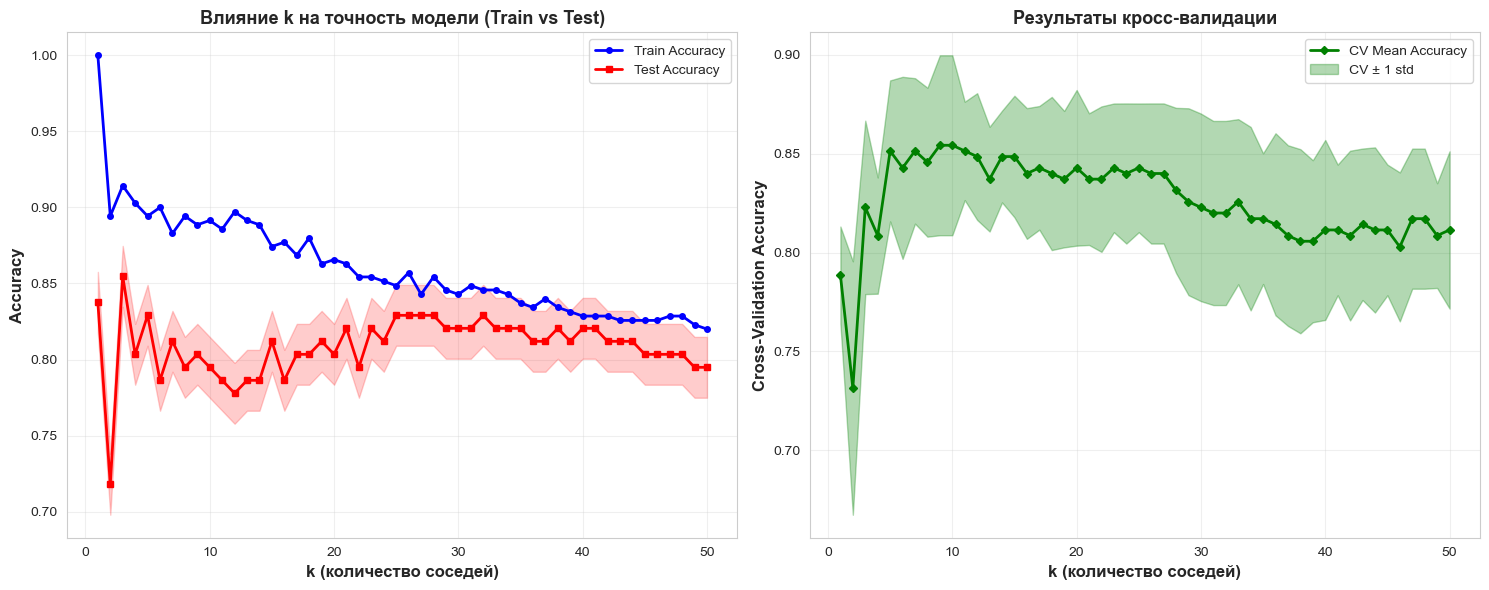

Оптимальное значение k: 9
CV Accuracy: 0.8543 (+/-0.0455)
Test Accuracy при k=9: 0.8034
Train Accuracy при k=9: 0.8886
Разница Train-Test: 0.0852


In [122]:
k_values = range(1, 51)

train_scores = []
test_scores = []
cv_scores_mean = []
cv_scores_std = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    
    knn.fit(X_train_scaled, y_train)

    train_acc = accuracy_score(y_train, knn.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    
    cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores_mean.append(cv_scores.mean())
    cv_scores_std.append(cv_scores.std())
    
    if k % 5 == 0:  
        print(f"k={k}: Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}, CV={cv_scores.mean():.4f} (+/-{cv_scores.std():.4f})")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(k_values, train_scores, marker='o', label='Train Accuracy', 
             linewidth=2, markersize=4, color='blue')
axes[0].plot(k_values, test_scores, marker='s', label='Test Accuracy', 
             linewidth=2, markersize=4, color='red')
axes[0].fill_between(k_values, 
                     [t - 0.02 for t in test_scores], 
                     [t + 0.02 for t in test_scores], 
                     alpha=0.2, color='red')
axes[0].set_xlabel('k (количество соседей)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Влияние k на точность модели (Train vs Test)', 
                  fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_values, cv_scores_mean, marker='D', label='CV Mean Accuracy', 
             linewidth=2, markersize=4, color='green')
axes[1].fill_between(k_values, 
                     np.array(cv_scores_mean) - np.array(cv_scores_std),
                     np.array(cv_scores_mean) + np.array(cv_scores_std),
                     alpha=0.3, color='green', label='CV ± 1 std')
axes[1].set_xlabel('k (количество соседей)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cross-Validation Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Результаты кросс-валидации', 
                  fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k_idx = np.argmax(cv_scores_mean)
optimal_k = k_values[optimal_k_idx]
optimal_cv_score = cv_scores_mean[optimal_k_idx]

print(f"Оптимальное значение k: {optimal_k}")
print(f"CV Accuracy: {optimal_cv_score:.4f} (+/-{cv_scores_std[optimal_k_idx]:.4f})")
print(f"Test Accuracy при k={optimal_k}: {test_scores[optimal_k_idx]:.4f}")
print(f"Train Accuracy при k={optimal_k}: {train_scores[optimal_k_idx]:.4f}")
print(f"Разница Train-Test: {train_scores[optimal_k_idx] - test_scores[optimal_k_idx]:.4f}")

Обучим финальную модель с k

In [124]:
final_knn = KNeighborsClassifier(n_neighbors=optimal_k, metric='euclidean')
final_knn.fit(X_train_scaled, y_train)

y_train_pred_knn = final_knn.predict(X_train_scaled)
y_test_pred_knn = final_knn.predict(X_test_scaled)
y_test_proba_knn = final_knn.predict_proba(X_test_scaled)[:, 1]

train_acc_knn = accuracy_score(y_train, y_train_pred_knn)
test_acc_knn = accuracy_score(y_test, y_test_pred_knn)
train_prec_knn = precision_score(y_train, y_train_pred_knn)
test_prec_knn = precision_score(y_test, y_test_pred_knn)
train_rec_knn = recall_score(y_train, y_train_pred_knn)
test_rec_knn = recall_score(y_test, y_test_pred_knn)
train_f1_knn = f1_score(y_train, y_train_pred_knn)
test_f1_knn = f1_score(y_test, y_test_pred_knn)
test_auc_knn = roc_auc_score(y_test, y_test_proba_knn)

print(f"Параметры модели: k={optimal_k}, metric='euclidean'")
print(f"\nМетрики на обучающей выборке:")
print(f"  Accuracy:  {train_acc_knn:.4f}")
print(f"  Precision: {train_prec_knn:.4f}")
print(f"  Recall:    {train_rec_knn:.4f}")
print(f"  F1-Score:  {train_f1_knn:.4f}")
print(f"\nМетрики на тестовой выборке:")
print(f"  Accuracy:  {test_acc_knn:.4f}")
print(f"  Precision: {test_prec_knn:.4f}")
print(f"  Recall:    {test_rec_knn:.4f}")
print(f"  F1-Score:  {test_f1_knn:.4f}")
print(f"  AUC-ROC:   {test_auc_knn:.4f}")
print(f"\nРазница Train-Test:")
print(f"  Accuracy: {(train_acc_knn - test_acc_knn):.4f}")
print(f"  F1-Score: {(train_f1_knn - test_f1_knn):.4f}")


print("\n")
print("Сравнение с логистической регрессией")

print(f"{'Метрика':<15} {'LogReg (Test)':<15} {'KNN (Test)':<15}")
print("-"*45)
print(f"{'Accuracy':<15} {test_accuracy:<15.4f} {test_acc_knn:<15.4f}")
print(f"{'Precision':<15} {test_precision:<15.4f} {test_prec_knn:<15.4f}")
print(f"{'Recall':<15} {test_recall:<15.4f} {test_rec_knn:<15.4f}")
print(f"{'F1-Score':<15} {test_f1:<15.4f} {test_f1_knn:<15.4f}")
print(f"{'AUC-ROC':<15} {auc_test:<15.4f} {test_auc_knn:<15.4f}")

Параметры модели: k=9, metric='euclidean'

Метрики на обучающей выборке:
  Accuracy:  0.8886
  Precision: 0.8881
  Recall:    0.9732
  F1-Score:  0.9287

Метрики на тестовой выборке:
  Accuracy:  0.8034
  Precision: 0.8333
  Recall:    0.9195
  F1-Score:  0.8743
  AUC-ROC:   0.8092

Разница Train-Test:
  Accuracy: 0.0852
  F1-Score: 0.0544


Сравнение с логистической регрессией
Метрика         LogReg (Test)   KNN (Test)     
---------------------------------------------
Accuracy        0.7949          0.8034         
Precision       0.8889          0.8333         
Recall          0.8276          0.9195         
F1-Score        0.8571          0.8743         
AUC-ROC         0.8870          0.8092         


Выводы:
1. Логистическая регрессия сильнее в точности результатов на 5.6%
2. У логистической регрессии AUC выше на 7.8%
3. У логистической регрессии выше интерпретируемость
4. KNN сильнее в recall (+9.2%)
5. KNN выше в доле правильных предсказаний среди всех объектов
6. У KNN проще концепция


Матрица ошибок:
  True Negatives (TN): 14 - правильно предсказаны 'Not Burnt Out'
  False Positives (FP): 16 - ошибочно предсказаны 'Burnt Out'
  False Negatives (FN): 7 - ошибочно предсказаны 'Not Burnt Out'
  True Positives (TP): 80 - правильно предсказаны 'Burnt Out'

Метрики ошибок:
  False Positive Rate: 0.5333 (доля ложных срабатываний)
  False Negative Rate: 0.0805 (доля пропущенных случаев)
  Error Rate: 0.1966


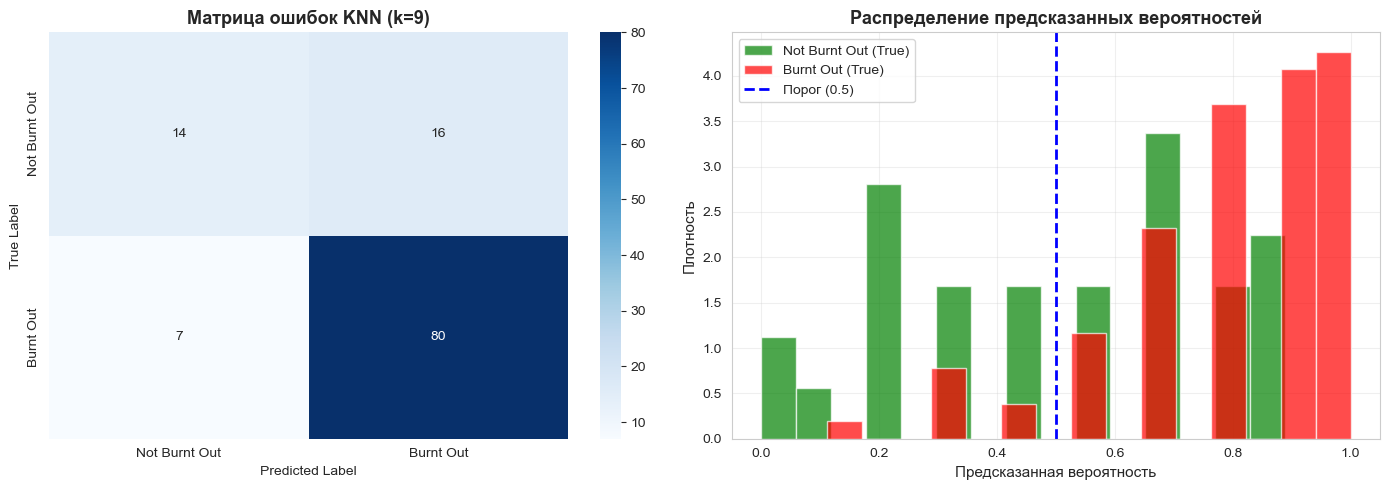


Характеристики ошибок:
  Количество ошибочных предсказаний: 23 из 117
  Процент ошибок: 19.66%
  Количество правильных предсказаний: 94 из 117
  Процент правильных: 80.34%


In [125]:
cm_knn = confusion_matrix(y_test, y_test_pred_knn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Burnt Out', 'Burnt Out'],
            yticklabels=['Not Burnt Out', 'Burnt Out'], ax=axes[0])
axes[0].set_title(f'Матрица ошибок KNN (k={optimal_k})', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

TN, FP, FN, TP = cm_knn.ravel()

print(f"\nМатрица ошибок:")
print(f"  True Negatives (TN): {TN} - правильно предсказаны 'Not Burnt Out'")
print(f"  False Positives (FP): {FP} - ошибочно предсказаны 'Burnt Out'")
print(f"  False Negatives (FN): {FN} - ошибочно предсказаны 'Not Burnt Out'")
print(f"  True Positives (TP): {TP} - правильно предсказаны 'Burnt Out'")

print(f"\nМетрики ошибок:")
print(f"  False Positive Rate: {FP/(FP+TN):.4f} (доля ложных срабатываний)")
print(f"  False Negative Rate: {FN/(FN+TP):.4f} (доля пропущенных случаев)")
print(f"  Error Rate: {(FP+FN)/(TP+TN+FP+FN):.4f}")

axes[1].hist(y_test_proba_knn[y_test == 0], bins=15, alpha=0.7, 
             label='Not Burnt Out (True)', color='green', density=True)
axes[1].hist(y_test_proba_knn[y_test == 1], bins=15, alpha=0.7, 
             label='Burnt Out (True)', color='red', density=True)
axes[1].axvline(x=0.5, color='blue', linestyle='--', linewidth=2, label='Порог (0.5)')
axes[1].set_xlabel('Предсказанная вероятность', fontsize=11)
axes[1].set_ylabel('Плотность', fontsize=11)
axes[1].set_title('Распределение предсказанных вероятностей', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

misclassified_idx = np.where(y_test_pred_knn != y_test)[0]
correct_idx = np.where(y_test_pred_knn == y_test)[0]

print(f"\nХарактеристики ошибок:")
print(f"  Количество ошибочных предсказаний: {len(misclassified_idx)} из {len(y_test)}")
print(f"  Процент ошибок: {len(misclassified_idx)/len(y_test)*100:.2f}%")
print(f"  Количество правильных предсказаний: {len(correct_idx)} из {len(y_test)}")
print(f"  Процент правильных: {len(correct_idx)/len(y_test)*100:.2f}%")

Модель KNN чаще присваивает здоровым ложный диагноз - в 53.3 случаях. 
16 человек ошибочно отнесены к группе риска и нужна дополнительная диагностика этих людей. 7 из 87 пропущены как выгоревшие - всего 8,05%.

Модель в 2.3 раза чаще ошибается в сторону ложных тревог, чем пропусков.

Оценим важность признаков с помощью permutation importance


Важность признаков (Permutation Importance):
 Признак  Важность  Стандартное отклонение
    cope  0.113105                0.033951
     loc  0.073789                0.025592
pastoral  0.027066                0.018475
teaching  0.007123                0.013796
  degree  0.003989                0.013006
  gender -0.004274                0.012629
research -0.023362                0.014460


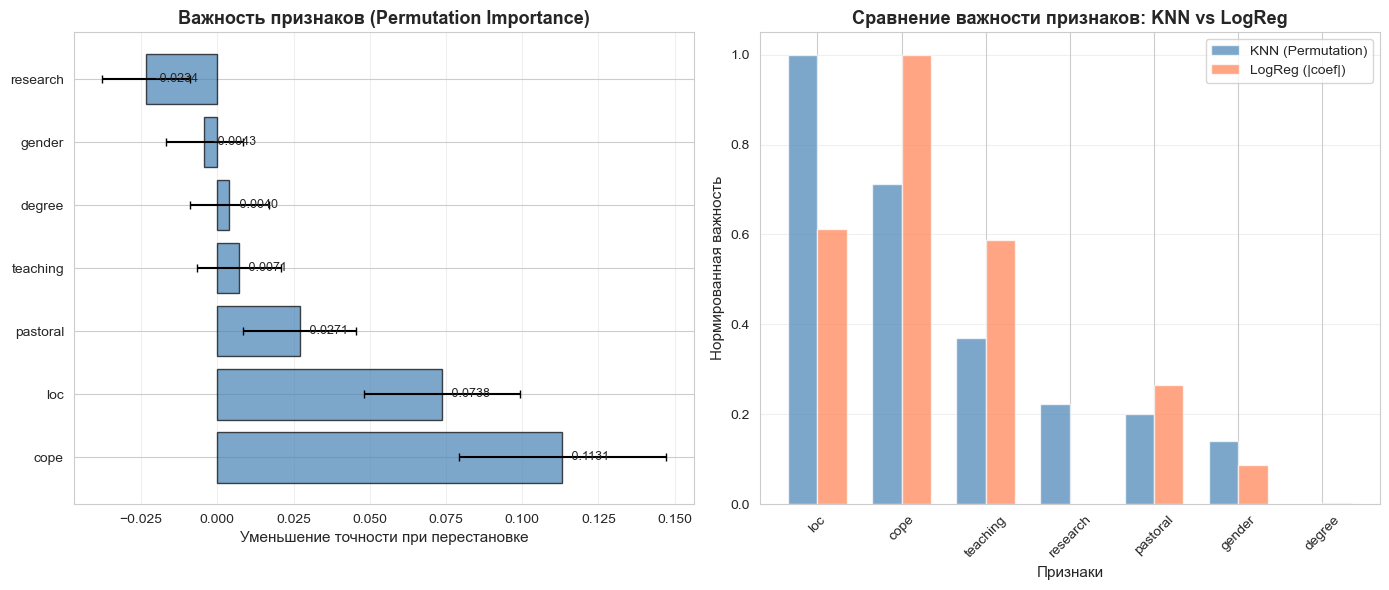

In [127]:
perm_importance = permutation_importance(final_knn, X_test_scaled, y_test, 
                                         n_repeats=30, random_state=42, scoring='accuracy')

feature_names_knn = ['loc', 'cope', 'teaching', 'research', 'pastoral', 'gender', 'degree']
importance_knn = pd.DataFrame({
    'Признак': feature_names_knn,
    'Важность': perm_importance.importances_mean,
    'Стандартное отклонение': perm_importance.importances_std
}).sort_values('Важность', ascending=False)

print("\nВажность признаков (Permutation Importance):")
print(importance_knn.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(importance_knn['Признак'], importance_knn['Важность'], 
             xerr=importance_knn['Стандартное отклонение'],
             color='steelblue', alpha=0.7, edgecolor='black', capsize=3)
axes[0].set_xlabel('Уменьшение точности при перестановке', fontsize=11)
axes[0].set_title('Важность признаков (Permutation Importance)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

for i, (idx, row) in enumerate(importance_knn.iterrows()):
    axes[0].text(row['Важность'] + 0.002, i, f' {row["Важность"]:.4f}', 
                 va='center', fontsize=9)

importance_knn_norm = importance_knn.copy()
importance_knn_norm['Важность_норм'] = (importance_knn_norm['Важность'] - importance_knn_norm['Важность'].min()) / \
                                         (importance_knn_norm['Важность'].max() - importance_knn_norm['Важность'].min())

logreg_importance = np.abs(log_reg.coef_[0])
logreg_importance_norm = (logreg_importance - logreg_importance.min()) / (logreg_importance.max() - logreg_importance.min())

x = np.arange(len(feature_names_knn))
width = 0.35

axes[1].bar(x - width/2, importance_knn_norm['Важность_норм'], width, 
            label='KNN (Permutation)', color='steelblue', alpha=0.7)
axes[1].bar(x + width/2, logreg_importance_norm, width, 
            label='LogReg (|coef|)', color='coral', alpha=0.7)
axes[1].set_xlabel('Признаки', fontsize=11)
axes[1].set_ylabel('Нормированная важность', fontsize=11)
axes[1].set_title('Сравнение важности признаков: KNN vs LogReg', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(feature_names_knn, rotation=45)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Наиболее важные признаки для KNN:
  1. cope: важность = 0.1131
  2. loc: важность = 0.0738
  3. pastoral: важность = 0.0271

Проанализируем влияние параметра k на обучение


Сравнение разных значений K:
 k  Train Acc  Test Acc  Train-Test Gap  CV Mean   CV Std Статус
 1   1.000000  0.837607        0.162393 0.788571 0.024578       
 9   0.888571  0.803419        0.085153 0.854286 0.045535       
50   0.820000  0.794872        0.025128 0.811429 0.039795       
Диаагности недообучения и переобучения

1. Малые значения K (k=1):
 Train Accuracy: 1.0000
 Test Accuracy: 0.8376
 Разрыв Train-Test: 0.1624

2. Оптимальное K (k=9):
  Train Accuracy: 0.8886
  Test Accuracy: 0.8034
  Разрыв Train-Test: 0.0852
  CV Score: 0.8543

3. Большие значения K (k=50):
   • Train Accuracy: 0.8200
   • Test Accuracy: 0.7949
   • Разрыв Train-Test: 0.0251


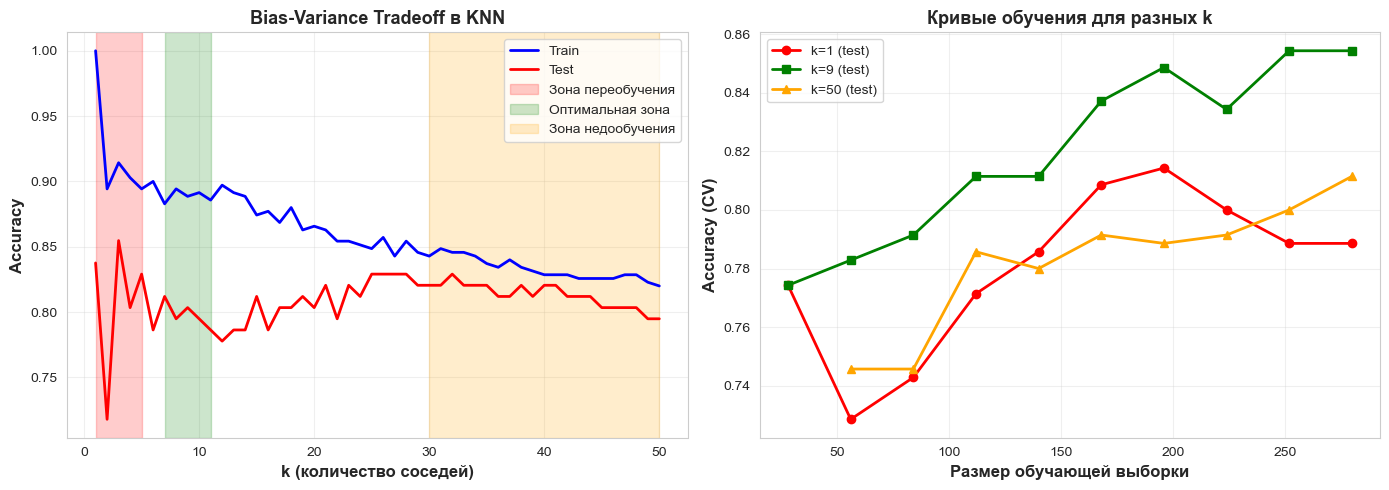

In [129]:
k_small = k_values[:5] 
k_optimal_range = range(max(1, optimal_k-3), min(51, optimal_k+4)) 
k_large = k_values[-5:] 

analysis_data = []

for k in [1, optimal_k, 50]:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    
    train_acc = accuracy_score(y_train, knn_temp.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, knn_temp.predict(X_test_scaled))
    
    cv_scores = cross_val_score(knn_temp, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    analysis_data.append({
        'k': k,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Train-Test Gap': train_acc - test_acc,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Статус': ''
    })

analysis_df = pd.DataFrame(analysis_data)

print("\nСравнение разных значений K:")
print(analysis_df.to_string(index=False))

print("Диаагности недообучения и переобучения")

print("\n1. Малые значения K (k=1):")
print(f" Train Accuracy: {analysis_df[analysis_df['k']==1]['Train Acc'].values[0]:.4f}")
print(f" Test Accuracy: {analysis_df[analysis_df['k']==1]['Test Acc'].values[0]:.4f}")
print(f" Разрыв Train-Test: {analysis_df[analysis_df['k']==1]['Train-Test Gap'].values[0]:.4f}")

print("\n2. Оптимальное K (k={}):".format(optimal_k))
print(f"  Train Accuracy: {analysis_df[analysis_df['k']==optimal_k]['Train Acc'].values[0]:.4f}")
print(f"  Test Accuracy: {analysis_df[analysis_df['k']==optimal_k]['Test Acc'].values[0]:.4f}")
print(f"  Разрыв Train-Test: {analysis_df[analysis_df['k']==optimal_k]['Train-Test Gap'].values[0]:.4f}")
print(f"  CV Score: {analysis_df[analysis_df['k']==optimal_k]['CV Mean'].values[0]:.4f}")

print("\n3. Большие значения K (k=50):")
print(f"   • Train Accuracy: {analysis_df[analysis_df['k']==50]['Train Acc'].values[0]:.4f}")
print(f"   • Test Accuracy: {analysis_df[analysis_df['k']==50]['Test Acc'].values[0]:.4f}")
print(f"   • Разрыв Train-Test: {analysis_df[analysis_df['k']==50]['Train-Test Gap'].values[0]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, train_scores, label='Train', linewidth=2, color='blue')
axes[0].plot(k_values, test_scores, label='Test', linewidth=2, color='red')
axes[0].axvspan(1, 5, alpha=0.2, color='red', label='Зона переобучения')
axes[0].axvspan(optimal_k-2, optimal_k+2, alpha=0.2, color='green', label='Оптимальная зона')
axes[0].axvspan(30, 50, alpha=0.2, color='orange', label='Зона недообучения')
axes[0].set_xlabel('k (количество соседей)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Bias-Variance Tradeoff в KNN', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

from sklearn.model_selection import learning_curve

train_sizes, train_scores_k1, test_scores_k1 = learning_curve(
    KNeighborsClassifier(n_neighbors=1), X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='accuracy',
    n_jobs=-1
)

train_sizes, train_scores_k_opt, test_scores_k_opt = learning_curve(
    KNeighborsClassifier(n_neighbors=optimal_k), X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='accuracy',
    n_jobs=-1
)

train_sizes, train_scores_k50, test_scores_k50 = learning_curve(
    KNeighborsClassifier(n_neighbors=50), X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='accuracy',
    n_jobs=-1
)

axes[1].plot(train_sizes, np.mean(test_scores_k1, axis=1), 'o-', 
             label=f'k=1 (test)', color='red', linewidth=2)
axes[1].plot(train_sizes, np.mean(test_scores_k_opt, axis=1), 's-', 
             label=f'k={optimal_k} (test)', color='green', linewidth=2)
axes[1].plot(train_sizes, np.mean(test_scores_k50, axis=1), '^-', 
             label=f'k=50 (test)', color='orange', linewidth=2)
axes[1].set_xlabel('Размер обучающей выборки', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy (CV)', fontsize=12, fontweight='bold')
axes[1].set_title('Кривые обучения для разных k', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Сложность модели KNN обратно пропорциональна k

Переобучение: при k меньше 6

Недообучение: при k более 12

Оптимальный баланс: k = 9 ± 3

Итоговые выводы 

1. Качество модели: 
Лучшее k: 9
Test Accuracy: 80.34%
Test F1-Score: 0.8743
Test AUC-ROC: 0.8092

2. Анализ ошибок
Всего ошибок: 23 из 117 (19.7%)
Доминируют ложные срабатывания (False Positives): 16
Модель чаще ошибочно классифицирует здоровых как выгоревших

3. Влияние K:
  • Маленькое k (k менее 10):
    - Высокая дисперсия, низкое смещение
    - Риск переобучения
    - Чувствительность к выбросам
  • Большое k (k более 30):
    - Низкая дисперсия, высокое смещение
    - Риск недообучения
    - Сглаживание важных границ
  • Оптимальное k = 9:
    - Сбалансированное смещение-дисперсия
    - Наилучшая обобщающая способность

ОПИСАНИЕ ИСПОЛЬЗОВАНИЯ ГЕНЕРАТИВНОЙ МОДЕЛИ

Использованная модель: DeepSeek (обновление апреля 2026) (доступ по адресу: https://chat.deepseek.com) 
Дата использования: 20.04.2026 - 27.04.2026

Части работы, подготовленные с использованием генеративной модели:
1. Генерация кода для визуализации данных с адаптацией
2. Генерация кода для обучения модели с адаптацией
3. Генерация кода для обучения логистической регрессии с адаптацией
4. Генерация кода для расчета метрик с адаптацией
5. Генерация кода для анализа регуляризации с адаптацией
6. Генерация кода для модели KNN

Цель применения: ускорения написания кода и его чистота и корректность, исследование различных вариантов решения задачи.